# EDA & Feature Engineering — Delivery ETA (Silver → Gold)

Objectif : comprendre ce qui influence `Time_taken(min)`, et créer des variables utiles à la modélisation.

## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from deliveryeta.paths import DELIVERY_DATA_S, DELIVERY_DATA_G

df = pd.read_csv(DELIVERY_DATA_S)
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Delivery_person_Age          41953 non-null  float64       
 1   Delivery_person_Ratings      41953 non-null  float64       
 2   Restaurant_latitude          41953 non-null  float64       
 3   Restaurant_longitude         41953 non-null  float64       
 4   Delivery_location_latitude   41953 non-null  float64       
 5   Delivery_location_longitude  41953 non-null  float64       
 6   Order_Date                   41953 non-null  datetime64[us]
 7   Time_Orderd                  41953 non-null  datetime64[us]
 8   Time_Order_picked            41953 non-null  str           
 9   Weatherconditions            41953 non-null  str           
 10  Road_traffic_density         41953 non-null  str           
 11  Vehicle_condition            41953 non-null  int64  

## 2. Séparation des variables

In [2]:
target = "Time_taken(min)"
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)

Numériques : ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Time_taken(min)']
Catégorielles : ['Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']


C:\Users\Elkerymy-Mohamed\AppData\Local\Temp\ipykernel_25768\202096464.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


## 3. Statistiques descriptives

In [3]:
for col in num_cols:
    print(f"\n----------{col}--------\n")
    print(df[col].describe())

for col in cat_cols:
    print(f"\n----------{col}--------\n")
    print(df[col].value_counts())


----------Delivery_person_Age--------

count    41953.000000
mean        29.581222
std          5.692692
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

----------Delivery_person_Ratings--------

count    41953.000000
mean         4.633802
std          0.325577
min          1.000000
25%          4.500000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

----------Restaurant_latitude--------

count    41953.000000
mean        18.911397
std          5.467829
min          9.957144
25%         12.986047
50%         19.065838
75%         22.751234
max         30.914057
Name: Restaurant_latitude, dtype: float64

----------Restaurant_longitude--------

count    41953.000000
mean        76.923408
std          3.502910
min         72.768726
25%         73.898520
50%         76.618203
75%         78.368855
max         88.433452
N

## 4. Distribution de la cible

`Time_taken(min)` est asymétrique à droite : la majorité des livraisons durent 15 à 35 min, pic vers 25-27 min, avec une longue traîne jusqu'à 54 min.

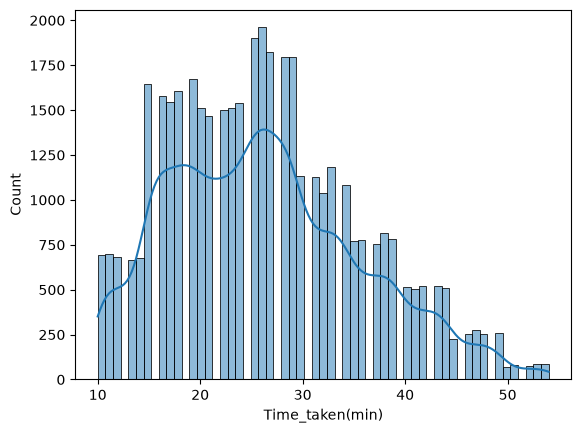

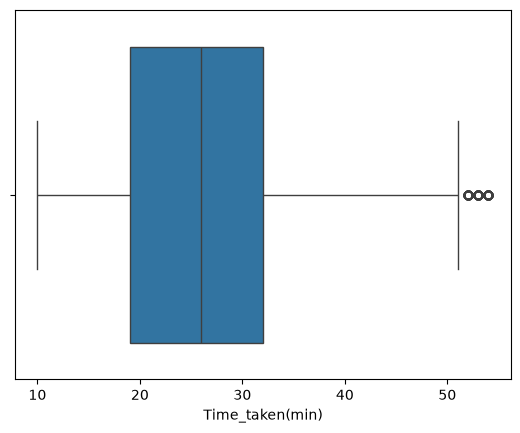

In [4]:
sns.histplot(df["Time_taken(min)"], kde=True)
plt.show()
sns.boxplot(x=df["Time_taken(min)"])
plt.show()

## 5. Cible vs variables catégorielles

- `Weatherconditions` : `Sunny` nettement plus rapide que `Cloudy`/`Fog`.
- `Road_traffic_density` : `Low` le plus rapide, `Jam` le plus lent — la variable catégorielle la plus discriminante.
- `Type_of_vehicle` : peu de différence entre types.

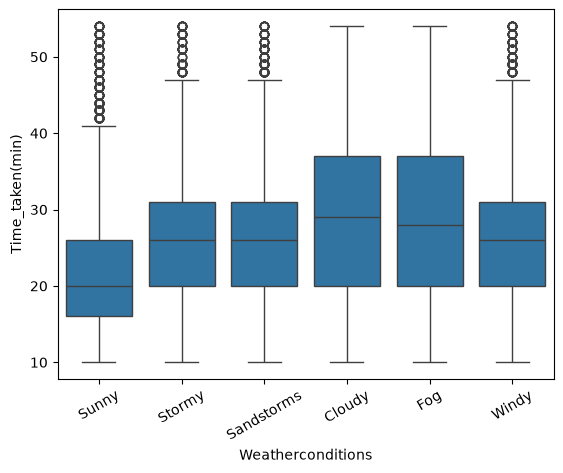

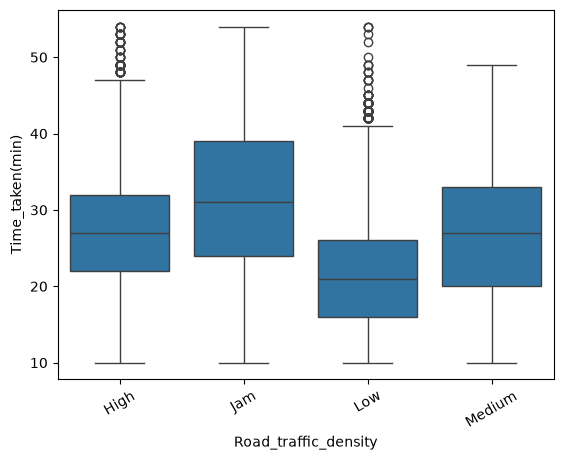

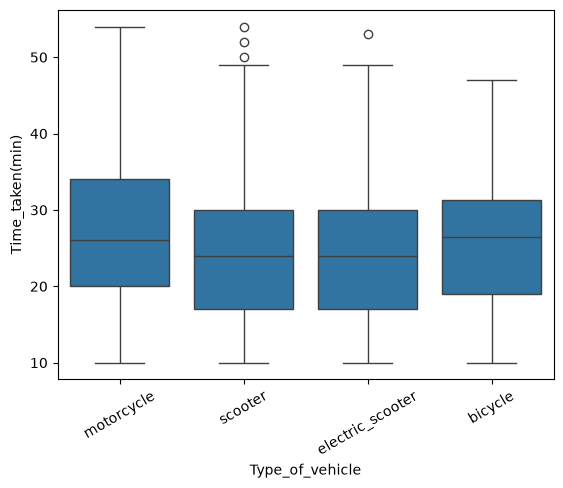

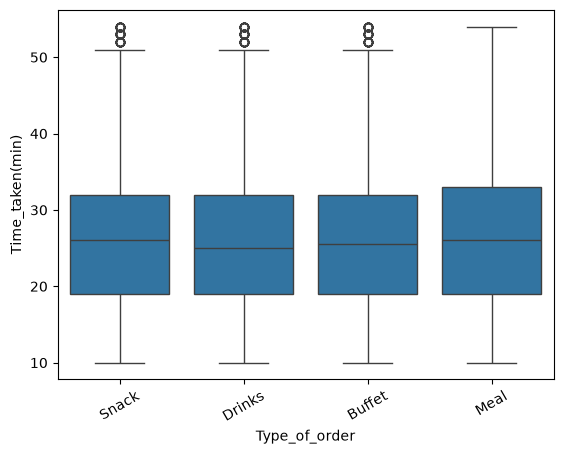

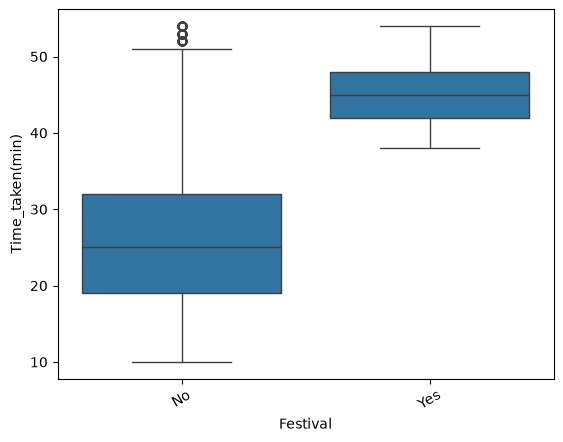

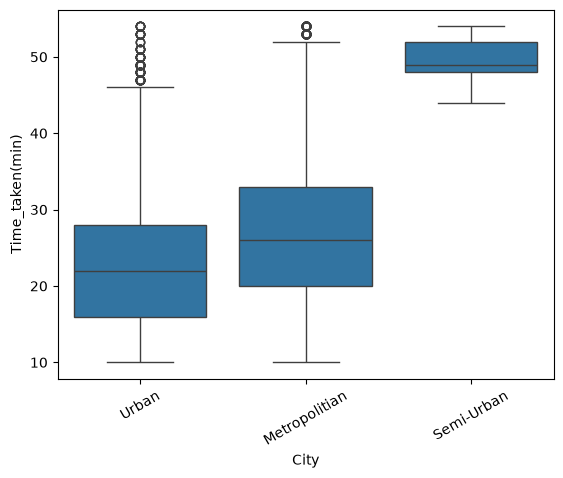

In [5]:
for col in ["Weatherconditions", "Road_traffic_density", "Type_of_vehicle", "Type_of_order", "Festival", "City"]:
    sns.boxplot(x=df[col], y=df["Time_taken(min)"])
    plt.xticks(rotation=30)
    plt.show()

## 6. Cible vs variables numériques

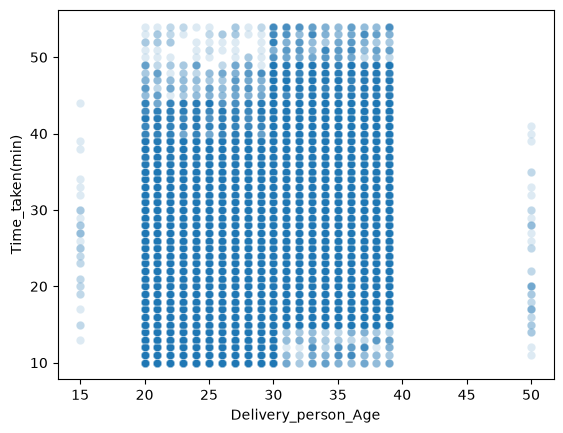

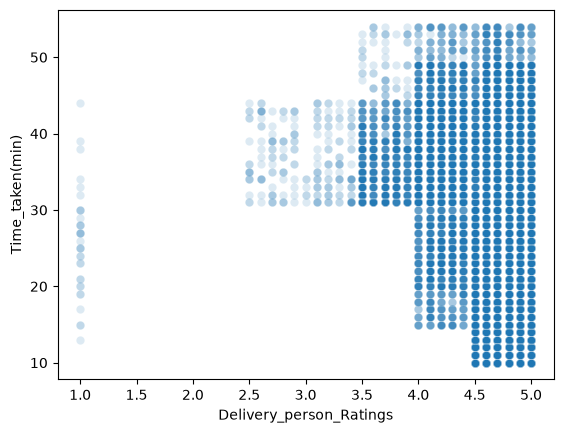

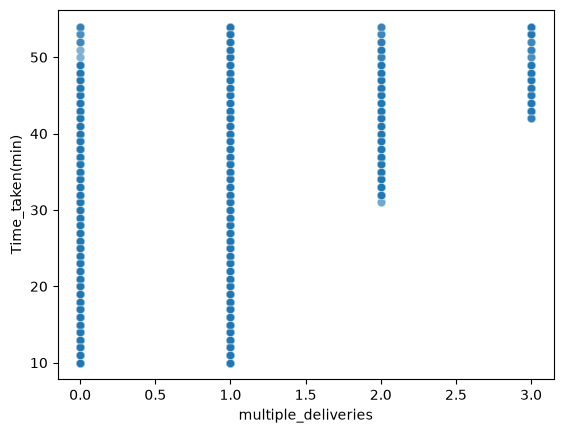

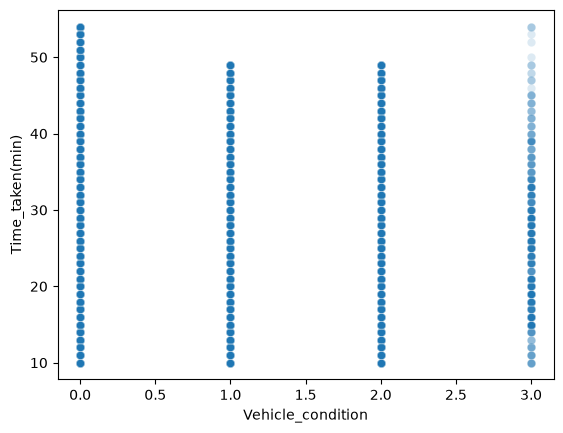

In [6]:
for col in ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", "Vehicle_condition"]:
    sns.scatterplot(x=df[col], y=df["Time_taken(min)"], alpha=0.15)
    plt.show()

## 7. Matrice de corrélation (variables numériques brutes)

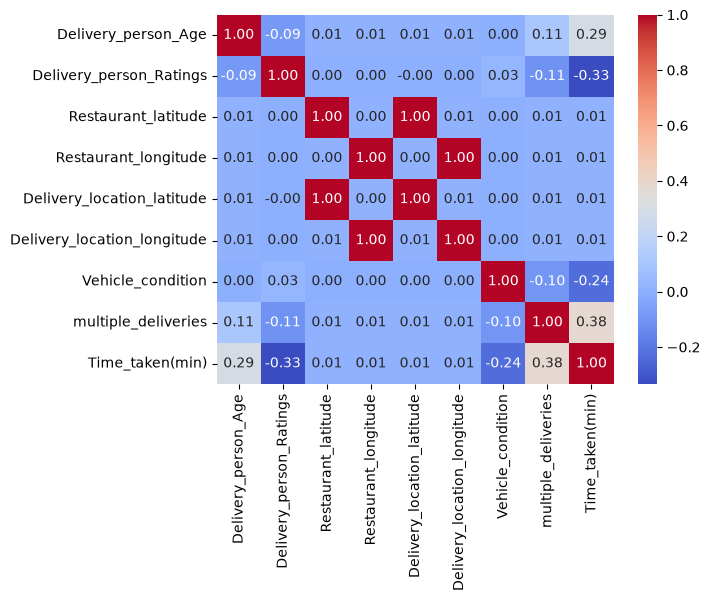

In [7]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

## 8. Feature engineering

### 8.1 Distance (`Distance_km`)
Distance à vol d'oiseau (haversine) entre restaurant et point de livraison.

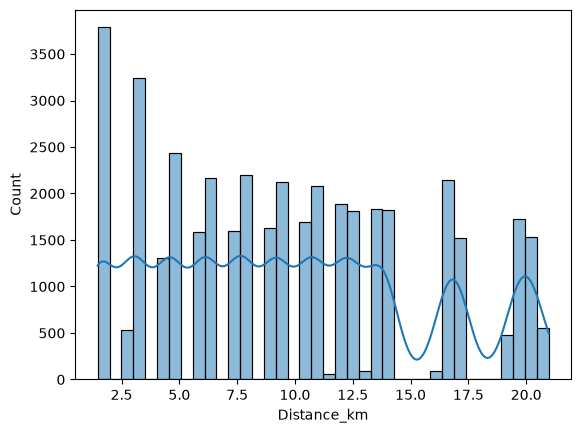

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return (R * 2 * np.arcsin(np.sqrt(a))).round(2)

df["Distance_km"] = haversine(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"]
)
sns.histplot(df["Distance_km"], kde=True)
plt.show()

### 8.2 Variables temporelles
`Order_Hour`, `Order_DayOfWeek`, `Is_Weekend`, et `Is_Rush_Hour` (déjeuner/dîner).

In [9]:
df["Order_Hour"] = df["Time_Orderd"].dt.hour
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek
df["Is_Weekend"] = df["Order_DayOfWeek"].isin([5, 6]).astype(int)
df["Is_Rush_Hour"] = df["Order_Hour"].isin([12, 13, 19, 20, 21]).astype(int)

### 8.3 Variable d'interaction : `Distance_x_Traffic`

`Road_traffic_density` a un ordre naturel (Low < Medium < High < Jam). Encodée en rang numérique (`Traffic_Rank`), puis multipliée par `Distance_km` : l'idée est qu'une longue distance **avec** du trafic dense pèse plus qu'une longue distance seule ou du trafic dense seul sur une courte distance.

In [10]:
traffic_rank = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df["Traffic_Rank"] = df["Road_traffic_density"].map(traffic_rank)
df["Distance_x_Traffic"] = df["Distance_km"] * df["Traffic_Rank"]

### 8.4 Validation des nouvelles variables

**Résultat déterminant** : l'interaction `Distance_x_Traffic` (0,448) est la variable numérique la plus corrélée à la cible du dataset — devant `Distance_km` seule (0,32) et `Traffic_Rank` seul (0,41). `Is_Rush_Hour` (0,342) est également bien plus informative que l'heure brute `Order_Hour` (0,184). `Is_Weekend` reste quasi nulle (-0,006), confirmant qu'elle n'apporte rien.

| Variable | Corrélation avec `Time_taken(min)` |
|---|---:|
| `Distance_x_Traffic` | **0,448** |
| `Traffic_Rank` | 0,412 |
| `Is_Rush_Hour` | 0,342 |
| `Distance_km` | 0,321 |
| `Order_Hour` | 0,184 |
| `Is_Weekend` | -0,006 |

In [11]:
feat_check = ["Distance_km", "Order_Hour", "Is_Weekend", "Is_Rush_Hour",
              "Traffic_Rank", "Distance_x_Traffic", "Time_taken(min)"]
df[feat_check].corr()["Time_taken(min)"].sort_values(ascending=False)

Time_taken(min)       1.000000
Distance_x_Traffic    0.448223
Traffic_Rank          0.411793
Is_Rush_Hour          0.342144
Distance_km           0.320546
Order_Hour            0.184168
Is_Weekend           -0.006435
Name: Time_taken(min), dtype: float64

## 9. Export du dataset enrichi

In [12]:
df_export = df.drop(columns=[
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "Order_Date", "Time_Orderd", "Time_Order_picked",
])
df_export.to_csv(DELIVERY_DATA_G, index=False)
print("Shape finale :", df_export.shape)
print("Sauvegardé :", DELIVERY_DATA_G)

Shape finale : (41953, 18)
Sauvegardé : C:\Users\Elkerymy-Mohamed\Study-DevAI\DeliveryETA\data\gold\delivery_data.csv


## 10. Résumé — variables candidates pour la modélisation

**Fortes** : `Distance_x_Traffic`, `Road_traffic_density`, `Weatherconditions`, `Traffic_Rank`, `Distance_km`, `Is_Rush_Hour`.
**Modérées** : `Delivery_person_Ratings`, `multiple_deliveries`, `Delivery_person_Age`, `Vehicle_condition`.
**Faibles** : `Type_of_vehicle`, `Type_of_order`, `City`, `Order_Hour`, `Is_Weekend` — conservées pour la comparaison de modèles, mais à surveiller en analyse d'importance.

Le dataset est prêt pour la modélisation (Jour 3).